# ARI5102 (Data Analysis Techniques) Assignment

UOM Assignment for the ARI5102 (Data Analysis Techniques) study-unit.

Author: [Michael Vella](michael.vella.20@um.edu.mt)

## Imports

Import any code packages required in this notebook

In [1]:
import warnings
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    mean_absolute_error,
    silhouette_score
)
from sklearn.cluster import AgglomerativeClustering
from sklearn import tree
from sklearn.decomposition import PCA
from sklearn.exceptions import DataConversionWarning
from kmedoids import KMedoids
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

from IPython.display import display

## Task 1

### Code

**Very simple Exploratory Data Analysis (EDA)**

We print very basic information on the DataFrame.

In [2]:
dataset_path = "data/dataset.csv"
pdf = pd.read_csv(dataset_path)

print(f"Dataset shape: {pdf.shape}")
print(f"\nColumn names: {pdf.columns.tolist()}")

print("\nDataset Info:")
display(pdf.info())

print("\nDataset Described:")
display(pdf.describe())

Dataset shape: (2500, 82)

Column names: ['q1_1', 'q2_1', 'q3_1', 'q3_2', 'q3_3', 'q3_4', 'q3_5', 'q3_6', 'q3_7', 'q3_8', 'q3_9', 'q3_10', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q4_5', 'q4_6', 'q4_7', 'q4_8', 'q4_9', 'q4_10', 'q5_1', 'q5_2', 'q5_3', 'q5_4', 'q5_5', 'q5_6', 'q5_7', 'q5_8', 'q5_9', 'q5_10', 'q6_1', 'q6_2', 'q6_3', 'q6_4', 'q6_5', 'q6_6', 'q6_7', 'q6_8', 'q6_9', 'q6_10', 'q7_1', 'q7_2', 'q7_3', 'q7_4', 'q7_5', 'q7_6', 'q7_7', 'q7_8', 'q7_9', 'q7_10', 'q8_1', 'q8_2', 'q8_3', 'q8_4', 'q8_5', 'q8_6', 'q8_7', 'q8_8', 'q8_9', 'q8_10', 'q9_1', 'q9_2', 'q9_3', 'q9_4', 'q9_5', 'q9_6', 'q9_7', 'q9_8', 'q9_9', 'q9_10', 'q10_1', 'q10_2', 'q10_3', 'q10_4', 'q10_5', 'q10_6', 'q10_7', 'q10_8', 'q10_9', 'q10_10']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 82 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   q1_1    2500 non-null   float64
 1   q2_1    2500 non-null   float64
 2   q3_1    2500 non-nul

None


Dataset Described:


,q1_1,q2_1,q3_1,q3_2,q3_3,q3_4,q3_5,q3_6,q3_7,q3_8,...,q10_1,q10_2,q10_3,q10_4,q10_5,q10_6,q10_7,q10_8,q10_9,q10_10
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.00000
mean,0.647200,0.454000,0.145600,0.048000,0.109200,0.074400,0.08320,0.109200,0.153200,0.068000,...,0.237200,0.177600,0.289600,0.233600,0.487600,0.261600,0.42440,0.196000,0.468000,0.19960
std,0.477937,0.497979,0.352775,0.213809,0.311952,0.262473,0.27624,0.311952,0.360252,0.251796,...,0.425451,0.382252,0.453667,0.423205,0.499946,0.439594,0.49435,0.397048,0.499075,0.39978
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.00000,0.000000,1.000000,0.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000


**Further analysis**

We analyse every question to determine the type of question it is and how many people answered.

In [3]:
def analyse_questions(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    n_respondents = len(df)

    # group columns by question prefix
    question_groups: dict[str, list[str]] = defaultdict(list)
    for col in columns:
        prefix = "_".join(col.split("_")[:-1]) # 'q3_1' results in 'q3'
        question_groups[prefix].append(col)

    records = []
    for question, cols in question_groups.items():
        question_df = df[cols]
        row_sums = question_df.sum(axis=1, skipna=True)
        is_multiple = (row_sums > 1).any()

        # a respondent skipped the question if ALL their values are NaN
        skipped_mask = question_df.isna().all(axis=1)
        n_missing = int(skipped_mask.sum())
        n_answered = n_respondents - n_missing
        pct_answered = 100 * n_answered / n_respondents

        records.append({
            "question"      : question,
            "possible_answers": len(cols),
            "selection_type": "multiple" if is_multiple else "single",
            "answered_by_all": n_missing == 0,
            "n_answered"    : n_answered,
            "n_missing"     : n_missing,
            "pct_answered"  : round(pct_answered, 1),
        })

    result = (
        pd.DataFrame(records)
        .set_index("question")
        .sort_index()
    )
    return result

summary = analyse_questions(pdf, pdf.columns.tolist())
display(summary)

,possible_answers,selection_type,answered_by_all,n_answered,n_missing,pct_answered
question,,,,,,
q1,1,single,True,2500,0,100.0
q10,10,multiple,True,2500,0,100.0
q2,1,single,True,2500,0,100.0
q3,10,single,True,2500,0,100.0
q4,10,single,True,2500,0,100.0
q5,10,single,True,2500,0,100.0
q6,10,multiple,False,1618,882,64.7
q7,10,multiple,True,2500,0,100.0
q8,10,multiple,False,1135,1365,45.4


### Answers

#### 1.1

The survey is made up of 10 different questions.

#### 1.2

The survey contains 2500 respondents.

#### 1.3

Questions 1, 2 are TRUE/FALSE questions. Questions 3, 4, 5 are multiple-choice questions where only one answer can be chosen (single-selection). The rest of the questions, which are 6, 7, 8, 9, 10 are multiple-selection questions. Questions 6 and 8 are do not apply to all of the respondents.

## Task 2

### Answers

#### 2.1

Since the goal is to predict the response pattern for each question separately, the choice of metric is tied to the output structure of each question type.

**For binary questions TRUE/FALSE questions (q1, q2)**, the prediction is a single binary label (0 or 1). Accuracy alone can be a poor choice if survey data exhibits a class imbalance. For example, if 85% of respondents selected option 1, a simple model that always predicts 1 would achieve 85% accuracy without learning anything useful. A more informative metric that can be used is the F1-score. This score measures the harmonic mean of precision and recall, which penalises models that simply predict the majority class.

**For single-select categorical questions (q3, q4, q5)**, the prediction is one class out of 10 mutually exclusive options and the problem can be modelled as a standard multi-class classification problem. In this case, one of the following metrics can be used:

- **F1-score per class**: Calculate the F1-score normally per specific class instance. In this case, we would end up with 10 F1-scores as we have 10 options. This is suitable for when we want to determine when specific options are being predicted poorly.
- **Macro average F1-score**: Takes the sum of the per class F1-scores and divide them by 10. Useful when all 10 options are equally important, especially under class imbalance.
- **Weighted average F1-score**: For each class, assign a weight. Multiply the class with that weight and sum all results together. Useful when misclassifying options that are rarely selected do not really matter (in such cases, you would give a very small weight to the options that don't matter a lot).
- **Micro average F1-score**: Calculate TP, FP, FN of all the classes. Then, work out the micro average F1-score using the following formula: *TP/(TP+0.5(FP+FN))*. Useful to reflect the overall correctness of all predictions.

**For multi-select questions (q6, q7, q8, q9, q10)**, the prediction is a binary vector (a set of 0s and 1s over 10 options), which is a multi-label classification problem. Choosing an evaluation metric is a bit more complicated here because a prediction might be partially correct (but not fully) correct. In this case, one of the following metrics can be used:

- **Micro average F1-score**: Explanation above applies here as well.
- **Exact match ratio**: The fraction of respondents for whom the entire predicted label vector exactly matches the true vector. A strict metric as a predicition is only "correct" if all selected and non-selected options are predicted perfectly. It is useful when the exact combination matters.
- **Jaccard Score (Intersection over Union)**: Measures the similarity between the predicted labels and the true labels for each sample.
- **Hamming Loss**: Measures the fraction of wrong labels relative to the total number of labels.

#### 2.2

Yes, significantly.

The question type determines the nature of the prediction target, which in turn dictates which metrics are mathematically meaningful and practically informative.

For binary questions, the target is a single scalar, and metrics suited for binary classification (F1) apply directly.

For single-select categorical questions, the target is one of K mutually exclusive classes. Multi-class extensions of classification metrics are needed and metrics designed for binary output must be adapted (for example, using a one-vs-rest scheme).

For multi-select questions, the target is a binary vector rather than a single label. Standard single-label classification metrics are no longer directly applicable because a prediction can be partially correct. Dedicated multi-label metrics are required to capture this structure.

## Task 3

### Code/Answers

#### 3.1.1 & 3.1.2

Split DataFrame into two (explanatory & response).

In [4]:
q5_cols = [f"q5_{i}" for i in range(1, 11)]
q6_cols = [f"q6_{i}" for i in range(1, 11)]
q8_cols = [f"q8_{i}" for i in range(1, 11)]

explanatory = pdf.drop(columns=q5_cols)
response = pdf[q5_cols]

print("Explanatory Variables:\n", explanatory.columns.tolist())
print("Response Variables:\n", response.columns.tolist())

Explanatory Variables:
 ['q1_1', 'q2_1', 'q3_1', 'q3_2', 'q3_3', 'q3_4', 'q3_5', 'q3_6', 'q3_7', 'q3_8', 'q3_9', 'q3_10', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q4_5', 'q4_6', 'q4_7', 'q4_8', 'q4_9', 'q4_10', 'q6_1', 'q6_2', 'q6_3', 'q6_4', 'q6_5', 'q6_6', 'q6_7', 'q6_8', 'q6_9', 'q6_10', 'q7_1', 'q7_2', 'q7_3', 'q7_4', 'q7_5', 'q7_6', 'q7_7', 'q7_8', 'q7_9', 'q7_10', 'q8_1', 'q8_2', 'q8_3', 'q8_4', 'q8_5', 'q8_6', 'q8_7', 'q8_8', 'q8_9', 'q8_10', 'q9_1', 'q9_2', 'q9_3', 'q9_4', 'q9_5', 'q9_6', 'q9_7', 'q9_8', 'q9_9', 'q9_10', 'q10_1', 'q10_2', 'q10_3', 'q10_4', 'q10_5', 'q10_6', 'q10_7', 'q10_8', 'q10_9', 'q10_10']
Response Variables:
 ['q5_1', 'q5_2', 'q5_3', 'q5_4', 'q5_5', 'q5_6', 'q5_7', 'q5_8', 'q5_9', 'q5_10']


**Compute distribution of all columns in the data**

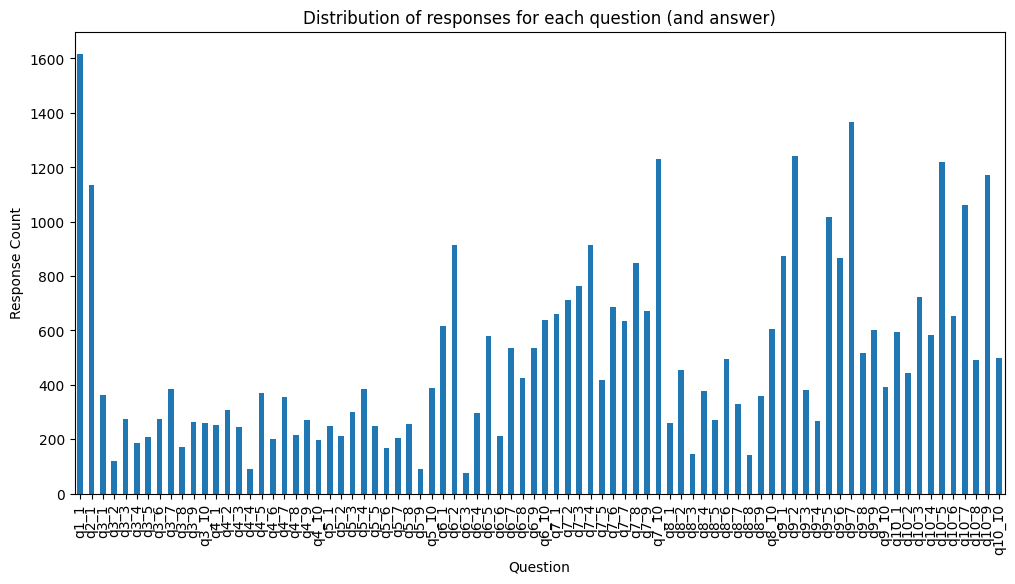

In [5]:
distribution = pdf.sum()

plt.figure(figsize=(12, 6))

distribution.plot(kind='bar')
plt.xlabel('Question')
plt.ylabel('Response Count')
plt.title('Distribution of responses for each question (and answer)')
plt.xticks(rotation=90)
plt.show()

**Analyse those questions that have sometimes been skipped**

We attempt to identify a pattern. Have they been skipped because the result is captured beforehand?

In [6]:
non_null_q6 = pdf.dropna(subset=q6_cols)
non_null_q8 = pdf.dropna(subset=q8_cols)

print("Shape of `pdf` DataFrame after dropping rows where all q6 were NULL:", non_null_q6.shape)
print("Shape of `pdf` DataFrame after dropping rows where all q8 were NULL:", non_null_q8.shape)

Shape of `pdf` DataFrame after dropping rows where all q6 were NULL: (1618, 82)
Shape of `pdf` DataFrame after dropping rows where all q8 were NULL: (1135, 82)


In fact, there is a pattern. Q6 is only answered when Q1 is True. Q8 is only answered when Q2 is True. This could mean that Q6 is a continuation of the Q1 TRUE/FALSE question and Q8 is a continuation of the Q2 TRUE/FALSE question.

In [7]:
response_distribution_q6 = non_null_q6.apply(pd.Series.value_counts).fillna(0)
response_distribution_q8 = non_null_q8.apply(pd.Series.value_counts).fillna(0)

display(response_distribution_q6.sort_values(by=1.0, axis=1, ascending=False))
display(response_distribution_q8.sort_values(by=1.0, axis=1, ascending=False))

,q1_1,q9_7,q7_10,q6_2,q10_9,q9_2,q2_1,q10_7,q10_5,q6_10,...,q5_1,q6_3,q4_1,q4_8,q4_4,q8_1,q3_2,q8_8,q5_9,q8_3
0.0,0.0,667,667,703,707,796,881,887,902,978,...,1532,1543,1545,1564,1565,689,1578,704,1587,714
1.0,1618.0,951,951,915,911,822,737,731,716,640,...,86,75,73,54,53,48,40,33,31,23


,q2_1,q1_1,q10_5,q9_5,q8_10,q9_7,q7_3,q7_2,q10_6,q10_9,...,q3_3,q9_4,q6_5,q3_10,q6_3,q4_4,q6_4,q3_4,q4_3,q5_9
0.0,0.0,398,426,436,530,536,538,543,567,593,...,1070,1081,687,1087,703,1103,705,1108,1109,1112
1.0,1135.0,737,709,699,605,599,597,592,568,542,...,65,54,50,48,34,32,32,27,26,23


**What should be done with Q6 & Q8 since we have NULL values inside of them?**

Two possible approaches:

1. Treat NULLs as 0. Since the dataset uses 1.0 to indicate a selected option, a missing response could reasonably be interpreted as the respondent not selecting any option for that question. This preserves all respondents in the training data and is the simplest approach. The risk is that "didn't answer" and "answered but selected nothing" may not be equivalent.
2. Drop the q6 and q8 columns entirely. Being that Q6 and Q8 are related to Q1 and Q2 respectively, it might be assumed that Q1 and Q2 contain enough information to represent the data in Q6 and Q8 and so they carry limited signal and may introduce noise.

Let's try both implementations and experiment with using a **Decision Tree Classifier**. We use a decision tree classifier for it's simplicity to both linear and non-linear relationships and also to be able to easily interpret the results due to the model's interpretability.

**Split into test/train**

We create the data as described in the two scenarios above and also split it into a test/train set with 70% for training and 30% for testing.

We also collapse the 10 binary q5 columns into one integer (1-10) by finding which column has the value 1. This will be used as our target variable.

In [8]:
scenario_one_explanatory = explanatory.fillna(0) # first scenario: treating NULLs as 0
scenario_two_explanatory = explanatory.drop(columns=q6_cols + q8_cols) # second scenario: dropping the q6 & q8 columns
y = response.idxmax(axis=1).str.extract(r"q5_(\d+)").astype(int).squeeze()

print("Scenario one features (shape):", scenario_one_explanatory.shape)
print("Scenario two features (shape):", scenario_two_explanatory.shape)

print("\nY Classes:")
display(y)

scenario_one_X_train, scenario_one_X_test, scenario_one_y_train, scenario_one_y_test = train_test_split(scenario_one_explanatory, y, test_size=0.3, random_state=42, stratify=response)
scenario_two_X_train, scenario_two_X_test, scenario_two_y_train, scenario_two_y_test = train_test_split(scenario_two_explanatory, y, test_size=0.3, random_state=42, stratify=response)

print("\nScenario 1 (treat NaNs as 0):")
print("X (Training):", scenario_one_X_train.shape)
print("X (Testing):", scenario_one_X_test.shape)
print("y (Training):", scenario_one_y_test.shape)
print("y (Testing):", scenario_one_y_test.shape)

print("\nScenario 2 (drop Q6 and Q8):")
print("X (Training):", scenario_two_X_train.shape)
print("X (Testing):", scenario_two_X_test.shape)
print("y (Training):", scenario_two_y_test.shape)
print("y (Testing):", scenario_two_y_test.shape)

Scenario one features (shape): (2500, 72)
Scenario two features (shape): (2500, 52)

Y Classes:


0        8
1        9
2        4
3        2
4        7
        ..
2495    10
2496     9
2497     4
2498     2
2499     4
Name: 0, Length: 2500, dtype: int64


Scenario 1 (treat NaNs as 0):
X (Training): (1750, 72)
X (Testing): (750, 72)
y (Training): (750,)
y (Testing): (750,)

Scenario 2 (drop Q6 and Q8):
X (Training): (1750, 52)
X (Testing): (750, 52)
y (Training): (750,)
y (Testing): (750,)


**Prepare grid search**

We prepare a grid search to be able to test the decision tree classifier with different hyperparameters. Since we have somewhat of a class imbalance, we use the f1 marco as the scoring as this assumes that all 10 options are equally important.

In [9]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator = dt,
    param_grid = param_grid,
    cv = 5,
    scoring = "f1_macro",
    n_jobs = -1,
    verbose = 1,
)

**Evaluate grid search**

Using grid search to find the best hyperparameters for the Decision Tree model on the two different scenarios described above.

For each scenario, once we identify the best hyperparameters, we train a decision tree model using the best hyperparameters and evaluate it using the metrics we proposed in **Task 2**.

**Scenario 1 restults**

Below are the results obtained for scenario 1 where we treat NULLs as 0.

In [10]:
grid_search.fit(scenario_one_X_train, scenario_one_y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-val Macro F1: {grid_search.best_score_:.4f}")

# fit the model using the best hyperparameters discovered during grid search
scenario_one_model = DecisionTreeClassifier(**grid_search.best_params_)
scenario_one_model.fit(scenario_one_X_train, scenario_one_y_train)
scenario_one_y_pred = scenario_one_model.predict(scenario_one_X_test)

acc = accuracy_score(scenario_one_y_test, scenario_one_y_pred)
f1_macro = f1_score(scenario_one_y_test, scenario_one_y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(scenario_one_y_test, scenario_one_y_pred, average="weighted", zero_division=0)
f1_micro = f1_score(scenario_one_y_test, scenario_one_y_pred, average="micro", zero_division=0)

print(f"\nAccuracy: {acc:.4f}")
print(f"Macro F1: {f1_macro:.4f} (all classes equally important)")
print(f"Weighted F1: {f1_weighted:.4f} (weighted by class frequency)")
print(f"Micro F1: {f1_micro:.4f} (aggregate TP/FP/FN across classes)")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-val Macro F1: 0.1376

Accuracy: 0.1720
Macro F1: 0.1531 (all classes equally important)
Weighted F1: 0.1652 (weighted by class frequency)
Micro F1: 0.1720 (aggregate TP/FP/FN across classes)


**Scenario 2 restults**

Below are the results obtained for scenario 2 where we drop columns 6 & 8.

In [11]:
grid_search.fit(scenario_two_X_train, scenario_two_y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-val Macro F1: {grid_search.best_score_:.4f}")

# fit the model using the best hyperparameters discovered during grid search
scenario_two_model = DecisionTreeClassifier(**grid_search.best_params_)
scenario_two_model.fit(scenario_two_X_train, scenario_two_y_train)
scenario_two_y_pred = scenario_two_model.predict(scenario_two_X_test)

acc = accuracy_score(scenario_two_y_test, scenario_two_y_pred)
f1_macro = f1_score(scenario_two_y_test, scenario_two_y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(scenario_two_y_test, scenario_two_y_pred, average="weighted", zero_division=0)
f1_micro = f1_score(scenario_two_y_test, scenario_two_y_pred, average="micro", zero_division=0)

print(f"\nAccuracy: {acc:.4f}")
print(f"Macro F1: {f1_macro:.4f} (all classes equally important)")
print(f"Weighted F1: {f1_weighted:.4f} (weighted by class frequency)")
print(f"Micro F1: {f1_micro:.4f} (aggregate TP/FP/FN across classes)")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross-val Macro F1: 0.1399

Accuracy: 0.1773
Macro F1: 0.1394 (all classes equally important)
Weighted F1: 0.1554 (weighted by class frequency)
Micro F1: 0.1773 (aggregate TP/FP/FN across classes)


**Results**

As can be seen in both scenarios, the low F1 score suggests that the remaining survey questions provide limited predictive signal for Q5.

Moreover, including/excluding questions 6 and 8 does not really make a substantinal difference in the prediction either. However, for the next question we will use the model obtained under the assumptions of scenario one (treating NaNs as 0).

#### 3.1.3

Due to its transparent nature, interpreting the decision tree is possible and we can do so by visualising it.

*We visualise it with a depth of 3 to keep it visibile in the screen*.

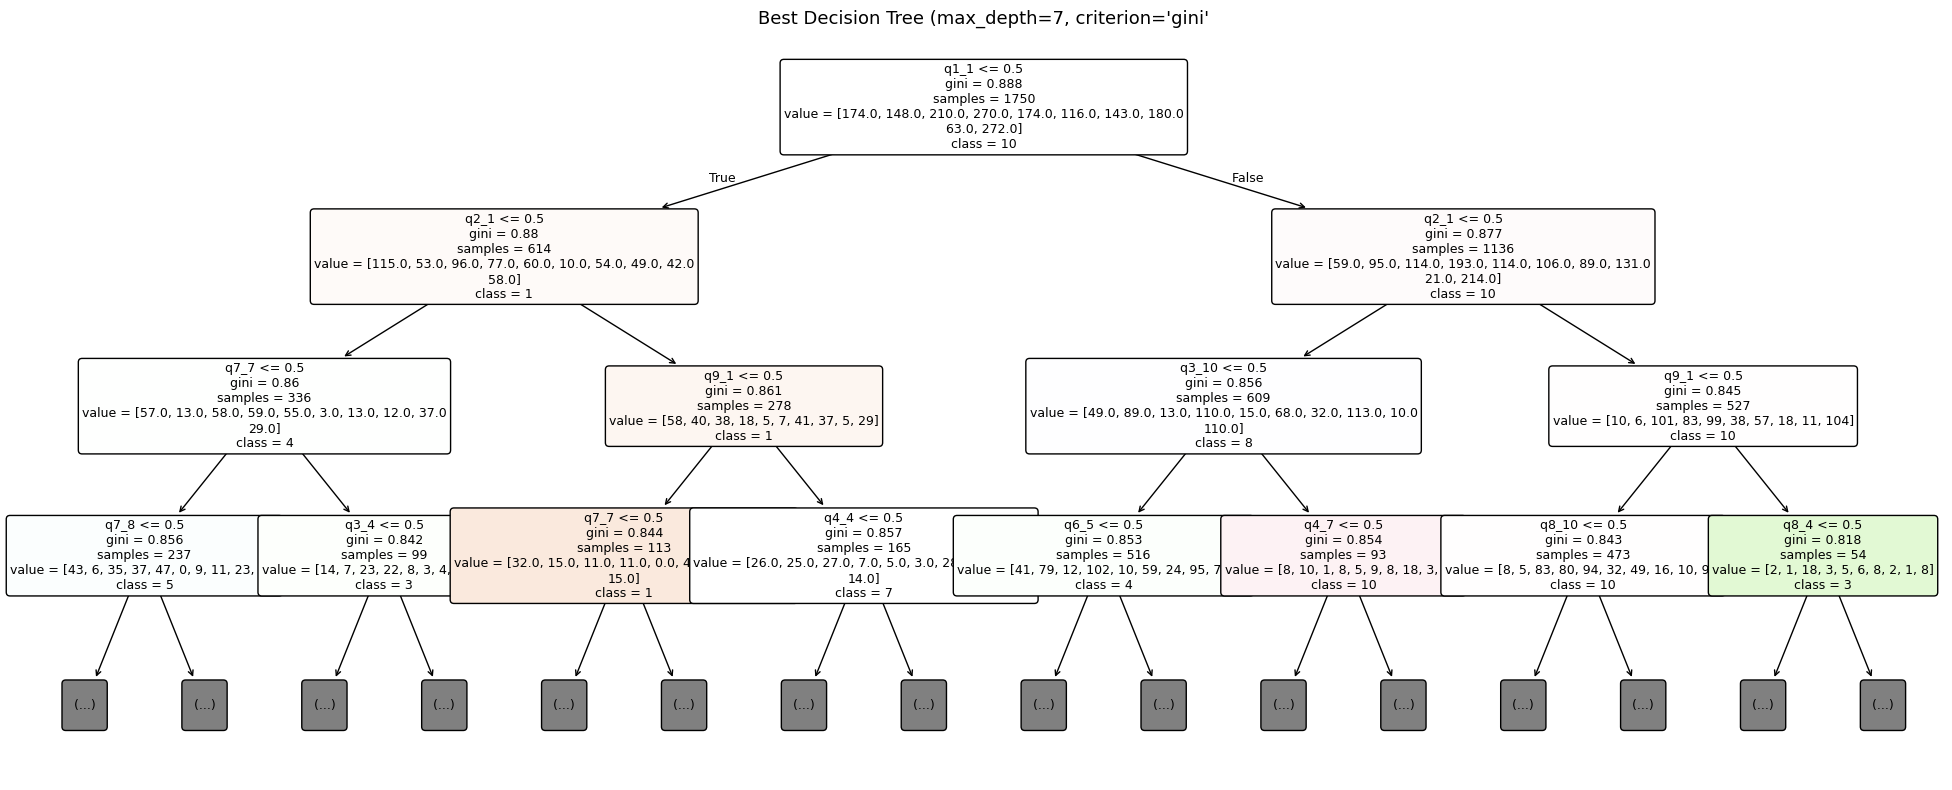

In [12]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    scenario_one_model,
    feature_names=scenario_one_explanatory.columns.tolist(),
    class_names=[str(i) for i in range(1, 11)],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    f"Best Decision Tree (max_depth=7, criterion='gini'",
    fontsize=13,
)
plt.tight_layout()
plt.show()

**Structure**:

The tree flows top to bottom. Each node asks a yes/no question about a single feature, and the data is split accordingly. Respondents satisfying the condition go left, those that don't go right.

**Each node contains**

- **The split condition** (e.g. q3_2 <= 0.5): the feature and threshold the tree is splitting on. Since our features are binary (0 or 1), this effectively means "did the respondent select this option?"
- **Gini/Entropy**: the impurity of that node. 0 means perfectly pure (all one class), higher means more mixed.
- **Samples**: how many training respondents reached this node.
- **Values**: the class breakdown of those samples across all 10 q5 options.
- **Class**: the majority class at this node, i.e. what the tree would predict here.

**Leaf Nodes**:

The nodes at the bottom with no further splits are leaf nodes and these represent the final predictions. The predicted class is whichever value is largest in the values list at that node.

**Feature Importance**

Decision Trees also allow us to display the importance of each feature.

As can be seen, questions 2 and 1 were the most important explanatory features.

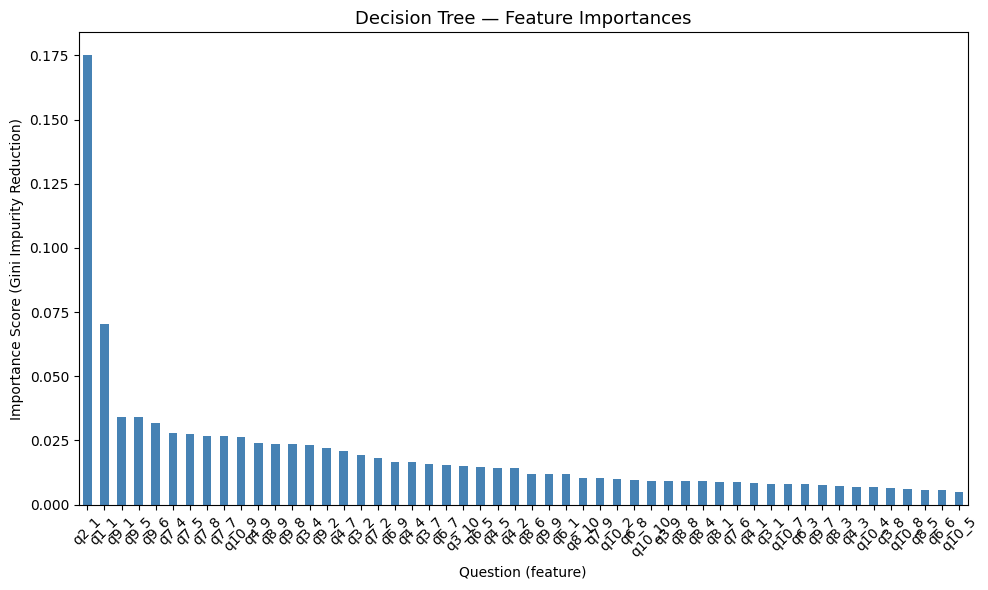

In [13]:
importances = pd.Series(scenario_one_model.feature_importances_, index=scenario_one_explanatory.columns)
importances_sorted = importances[importances > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances_sorted.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Decision Tree — Feature Importances", fontsize=13)
ax.set_ylabel("Importance Score (Gini Impurity Reduction)")
ax.set_xlabel("Question (feature)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

#### 3.2.1

Assuming that question 5 is ordinal, we can use a **Decision Tree Regression Model** to handle the ordinal nature of the target variables.

In ordinal problems, we can no longer use evaluation metrics that were used for the classification. This is because evaluation metrics used in classification problems do not consider the order, when in ordinal problems, the order is very important. For example, predicting a 1 when the expected answer was a 10 is much worse than predicting a 9. 

In [14]:
X_train = scenario_one_X_train 
X_test = scenario_one_X_test
y_train = scenario_one_y_train
y_test = scenario_one_y_test

dt_reg = DecisionTreeRegressor(random_state=42)

param_grid_reg = {
    "max_depth"        : [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf" : [1, 2, 5, 10],
}

grid_search_reg = GridSearchCV(
    estimator = dt_reg,
    param_grid = param_grid_reg,
    cv = 5,
    scoring = "neg_mean_absolute_error",
    n_jobs = -1,
)

grid_search_reg.fit(X_train, y_train)
best_dt_reg = grid_search_reg.best_estimator_

y_pred_reg = best_dt_reg.predict(X_test)
y_pred_rounded = y_pred_reg.round().clip(1, 10).astype(int)

print("Best parameters:", grid_search_reg.best_params_)

Best parameters: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}


#### 3.2.2

Evaluate decision tree regression model built to predict Q5 in the case that order is important.

We will use two metrics:

- **Mean Absolute Error (MAE)**: Measures the average absolute difference between the predicted class and the true class. Unlike standard classification metrics, it respects the ordinal structure of q5. A prediction that is one step away from the truth incurs less penalty than one that is five steps away.
- **Spearman Correlation**: Measures the rank-order agreement between the predicted and actual values, ranging from -1 (perfect inverse ranking) to +1 (perfect ranking agreement). It assesses whether the model correctly orders respondents relative to each other, regardless of the exact predicted value.

**Final results**:

The MAE of 2.48 and Spearman correlation of 0.20, suggest that the remaining survey questions provide only weak predictive signal for the ordinal ranking of q5. This is consistent with the results obtained in the multi-classification part above.

In [15]:
mae = mean_absolute_error(y_test, y_pred_rounded)
print(f"Mean Absolute Error: {mae:.4f}")

# spearman Correlation — measures rank-order agreement between predicted and actual
spearman_corr, p_value = spearmanr(y_test, y_pred_rounded)
print(f"Spearman Correlation: {spearman_corr:.4f} (p={p_value:.4f})")

Mean Absolute Error: 2.4813
Spearman Correlation: 0.1951 (p=0.0000)


## Task 4

### Code/Answers

#### 4.1

Different clustering algorithms can be used to group like-minded respondents together. Being that we have binary data and not categorial/ordinal data, we need to use clustering techniques that handle this type of data. For this exercise, we will experiment with the following clustering algorithms, using the Jaccard distance function.

- *K-Medoids*: Similar to K-Means, but instead of computing an abstract centroid, it selects an actual data point (the medoid) as each cluster's representative, defined as the member that minimises the total Jaccard distance to all others in its cluster. This makes it naturally compatible with binary data, since the medoid is always a valid response vector.
- *Hierarchical*: Builds a nested structure of groupings visualised as a dendrogram. This can be constructed in two directions: agglomerative (bottom-up), where each respondent starts as its own cluster and the two closest are iteratively merged or divisive (top-down), where all respondents begin in a single cluster that is recursively split. The desired number of clusters is chosen by cutting the dendrogram at an appropriate height. The result is affected by the choice of linkage criterion. Average or complete linkage is generally preferred over single linkage.

**Cluster input preparation**

Create a DataFrame from the previous DataFrame where we defaulted NULLs to 0s.

We compute the jaccard distance for every pair in the DataFrame.

In [16]:
cluster_df = scenario_one_explanatory.copy()

jaccard_dist = squareform(pdist(cluster_df.astype(bool), metric="jaccard"))
print("Shape of array after computing jaccard distance between every point:", jaccard_dist.shape) # N x N

Shape of array after computing jaccard distance between every point: (2500, 2500)


**Hierarchical Clustering**

Let's find the best number of clusters using the silhoutte score. The silhoutte score measures how similar an object is to its own cluster compared to other clusters.

In [17]:
scores = {}
for k in range(2, 10):
    labels = AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="complete",
    ).fit_predict(jaccard_dist)

    scores[k] = silhouette_score(jaccard_dist, labels, metric="precomputed")

best_k = max(scores, key=scores.get)

print("Silhoutte scores:", scores)
print("Ideal number of clusters:", best_k)

Silhoutte scores: {2: 0.026484213411582903, 3: 0.03795916412151113, 4: -0.011695983522629258, 5: -0.006608354818646309, 6: 0.02404290048545669, 7: 0.026448134004294833, 8: 0.029834810637059627, 9: 0.057939280369465315}
Ideal number of clusters: 9


Best cluster size is 9 so let's build a final hierarchical cluster using 9 clusters.

However, cluster size of 9 still produces a very bad silhoutte score so this type of clustering technique is not very useful anyway.

In [18]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=9,
    metric="precomputed",
    linkage="complete",
)

hierarchical_labels = hierarchical_model.fit_predict(jaccard_dist)

hierarchical_cluster_df = cluster_df.copy()
hierarchical_cluster_df["cluster"] = hierarchical_labels

print("Number of respondents per cluster:")
print(hierarchical_cluster_df['cluster'].value_counts())

Number of respondents per cluster:
cluster
1    737
2    721
0    397
5    387
4    113
3     40
8     38
6     35
7     32
Name: count, dtype: int64


**K-Medoids Clustering**

Finding the ideal K using the elbow technique.

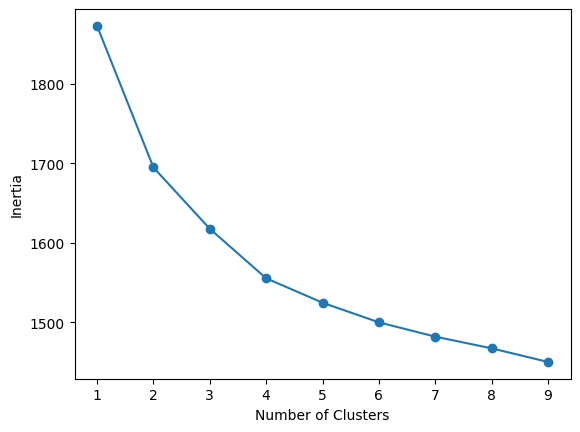

In [19]:
warnings.filterwarnings("ignore", category=DataConversionWarning, module='sklearn.metrics.pairwise')

means = []
inertias = []

for k in range(1, 10):
    kmedoids = KMedoids(
        n_clusters=k,
        metric="precomputed",
        method="fasterpam",
        init="random",
        random_state=0,
    )
    kmedoids.fit(jaccard_dist)
    means.append(k)
    inertias.append(kmedoids.inertia_)
        
plt.plot(means, inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Let's use a cluster size of 4 as it is around 3/4 that we get the 'elbow'.

In [20]:
medoid_model = KMedoids(
    n_clusters=4,
    metric="precomputed",
    method="fasterpam",
)

medoid_labels = medoid_model.fit(jaccard_dist).labels_

medoid_cluster_df = cluster_df.copy()
medoid_cluster_df["cluster"] = medoid_labels

print("Number of respondents per cluster:")
print(medoid_cluster_df['cluster'].value_counts())

Number of respondents per cluster:
cluster
0    850
1    744
3    506
2    400
Name: count, dtype: int64


#### 4.2


Because clustering is an unsupervised task, there are no ground-truth labels against which the resulting groups can be validated. The quality of a clustering must therefore be judged on the principle that a good solution exhibits low within-cluster dissimilarity (respondents assigned to the same group give similar answers) and high between-cluster dissimilarity (the groups are well separated from one another).

To quantify this, we can use the Silhouette Coefficient. For each respondent it contrasts the average distance to the other members of its own cluster with the average distance to the members of the nearest neighbouring cluster, yielding a value in the range [−1, 1], where higher values indicate better-defined clusters. Its key advantage in this setting is that it is defined for any distance metric, so it remains valid for clusters obtained using the Jaccard distance on the binary survey responses.

The Davies–Bouldin index is another common internal measure, but as it relies on cluster centroids and Euclidean distance it is not well suited to a Jaccard-based solution, so it's not reasonable to adopt it here.

#### 4.3

As explained in the previous section, let's compare the Silhouette Coefficient for both clustering algorithms.

In [21]:
medoid_silhouette = silhouette_score(jaccard_dist, medoid_labels, metric="precomputed")
hierarchical_silhouette = silhouette_score(jaccard_dist, hierarchical_labels, metric="precomputed")

print(f"K-Medoids (K=4) silhouette: {medoid_silhouette:.4f}")
print(f"Hierarchical (K=9) silhouette: {hierarchical_silhouette:.4f}")

K-Medoids (K=4) silhouette: 0.1273
Hierarchical (K=9) silhouette: 0.0579


K-Medoids achieved a score of 0.127 against 0.058 for the hierarchical solution, so K-Medoids is preferred.

Two further observations support this choice. K-Medoids attains the higher score while using fewer clusters (4 versus 9), whereas the hierarchical solution separates respondents less well despite partitioning them into more than twice as many groups. This could be a sign that the hierarchical clustering algorithm over-fragments the data into groups that are not meaningfully distinct.

However, it's important to note that both silhouette scores are low which indicates that the respondents do not form strongly separated natural clusters in general.

Given this information, we will use the K-Medoids algorithm moving forward.

#### 4.4

For each cluster, we can summarise how each respondent in that cluster answered each question.

Since we have binary data, we can sum the answers per question and plot the results to try and find a pattern.

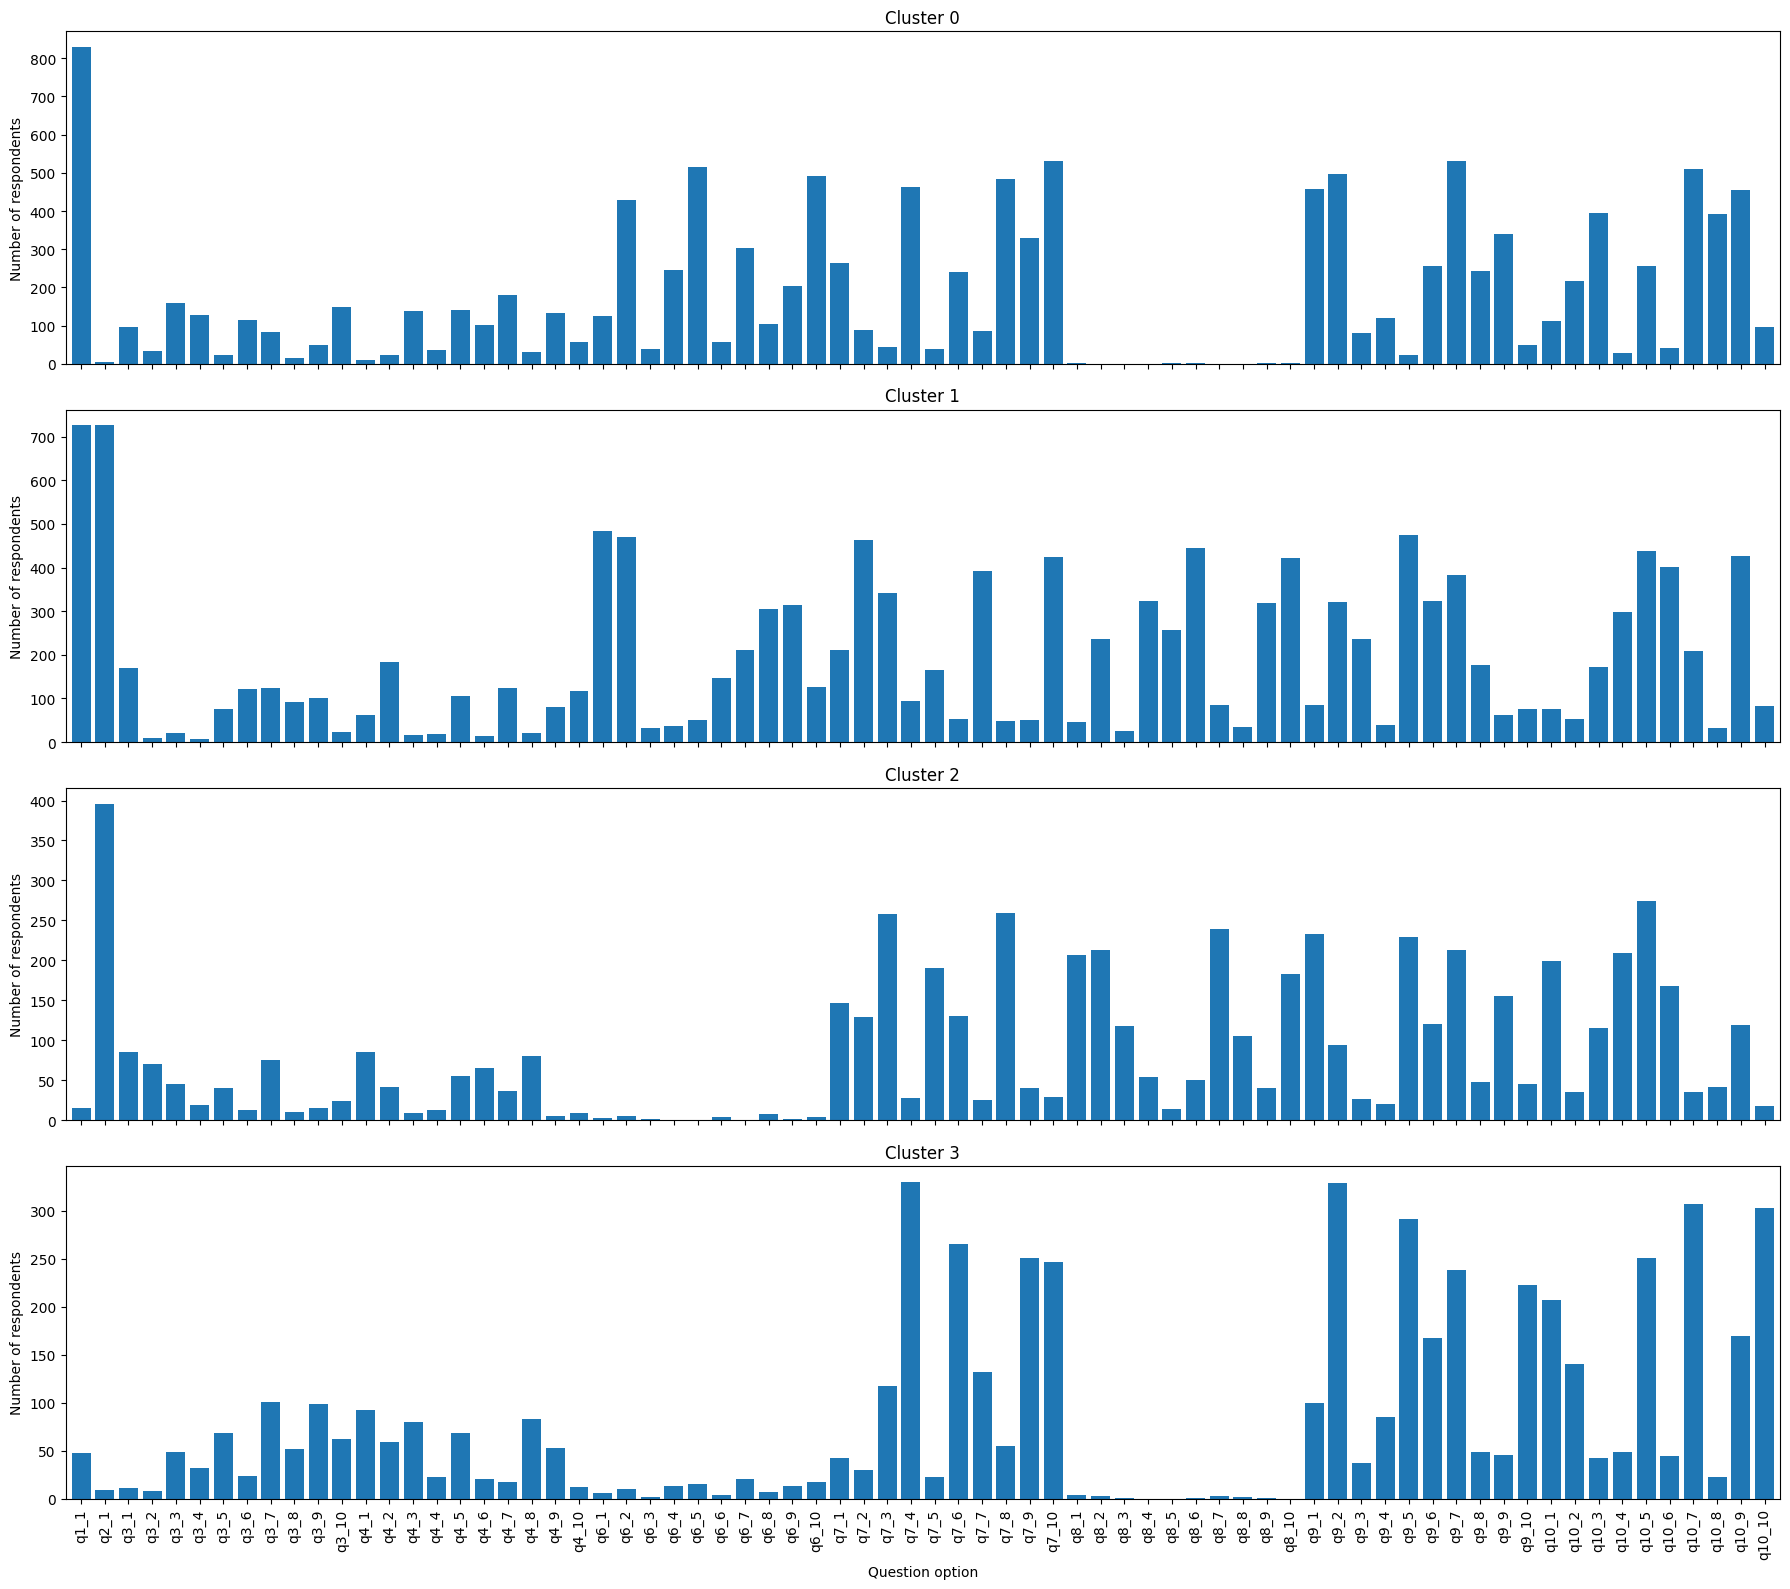

In [22]:
response_profile = medoid_cluster_df.groupby("cluster").sum().T

clusters = response_profile.columns
fig, axes = plt.subplots(
    len(clusters), 1,
    figsize=(18, 4 * len(clusters)),
    sharex=True,
)

for ax, cluster_id in zip(axes, clusters):
    response_profile[cluster_id].plot.bar(ax=ax, width=0.8)
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_ylabel("Number of respondents")

axes[-1].set_xlabel("Question option")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Using columns `q1` and `q2`, we can see a pattern as to how the clusters have been assigned.

- Respondents in cluster 0 tend to answer TRUE for `q2`.
- Respondents in cluster 1 tend to answer FALSE in both `q1` and `q2`.
- Respondents in cluster 2 tend to answer TRUE in both `q1` and `q2`.
- Respondents in cluster 3 tend to answer TRUE for `q1`.

#### 4.5

Let's perform some visualisations on the clusters.

We first visualise how many respondents there are per cluster.

Then, we perform PCA response data down to two dimensions so that the clustering can be displayed on a scatter plot. Each respondent is plotted using its first two principal components and coloured by its assigned cluster, with the medoids highlighted to show the representative respondent at the centre of each group. This lets us see how distinct the four clusters are and how much they overlap. 

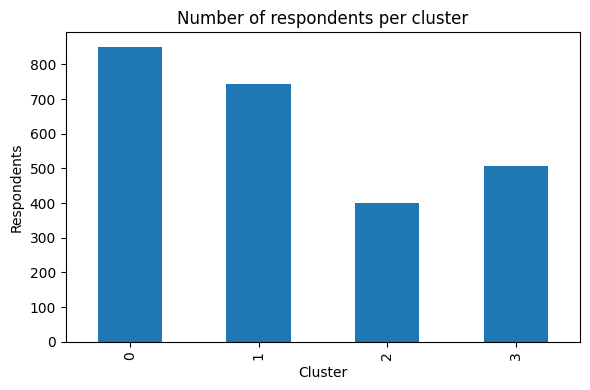

In [23]:
plt.figure(figsize=(6, 4))
medoid_cluster_df["cluster"].value_counts().sort_index().plot.bar()
plt.title("Number of respondents per cluster")
plt.xlabel("Cluster")
plt.ylabel("Respondents")
plt.tight_layout()
plt.show()

Variance explained by 2 components: 0.195


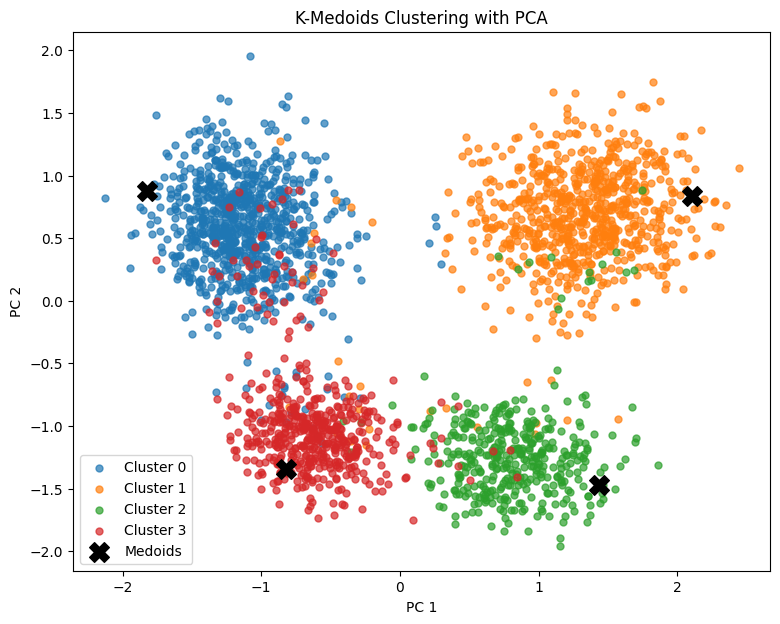

In [24]:
features = medoid_cluster_df.drop(columns=["cluster"])

pca_model = PCA(n_components=2)
coords = pca_model.fit_transform(features)
pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])

print("Variance explained by 2 components:", round(pca_model.explained_variance_ratio_[:2].sum(), 3))

plt.figure(figsize=(9, 7))
plt.title("K-Medoids Clustering with PCA")

for cluster_id in sorted(medoid_cluster_df["cluster"].unique()):
    mask = medoid_cluster_df["cluster"].values == cluster_id
    plt.scatter(coords[mask, 0], coords[mask, 1], s=25, alpha=0.7,
                label=f"Cluster {cluster_id}")

if hasattr(medoid_model, "medoid_indices_"):
    m = medoid_model.medoid_indices_
    plt.scatter(coords[m, 0], coords[m, 1], c="black", marker="X",
                s=200, label="Medoids")

plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.legend()
plt.show()

We applied PCA to project the 72-dimensional response data onto its first two principal components so that the clustering could be visualised in two dimensions. However, these two components together explain only 19% of the total variance, meaning the scatter plot captures a small fraction of the structure in the data while the remaining ~81% is collapsed away. The visualisation should therefore be read as an approximate guide to how the clusters relate rather than a faithful representation, which is consistent with the modest silhouette score and reflects the high-dimensional, binary nature of the survey responses.

#### 4.6

TO CONTINUE

## (Informal) References:

- [Jaccard Similarity Made Simple: A Beginner’s Guide to Data Comparison](https://mayurdhvajsinhjadeja.medium.com/jaccard-similarity-34e2c15fb524)
- [What is Jaccard similarity? | IBM](https://www.ibm.com/think/topics/jaccard-similarity)
- [What is a decision tree? | IBM](https://www.ibm.com/think/topics/decision-trees)
- [Spearman's Rank-Order Correlation](https://statistics.laerd.com/statistical-guides/spearmans-rank-order-correlation-statistical-guide.php)